# Stage 7 — Statewide Application (frozen method)

Applies the method developed and frozen at Mole Creek (Stages 2, 3, 5, 6) across the whole of Tasmania at a coarser resolution. Per the plan: "the workflow was developed and tested at the Mole Creek case-study scale," then applied statewide as-is, so Stage 8 can compare the two.

**Skipped here:** the Stage 2 geology cross-check and the Stage 3 DEM flow-accumulation comparison were validation exercises at Mole Creek, so they are not repeated statewide. Only the frozen formula runs.

Karst scoring and the pressure fetch come from `src/karst.py` and `src/landuse.py`, so the Mole Creek and statewide runs share one implementation.

**Resolution:** coarsened to **100 m** (from the native 25 m DEM built in Stage 1). The full statewide pipeline runs in about 20 seconds at this resolution, so there was no need to go coarser.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from karst import add_karst_susceptibility, add_connectivity, rasterize_max, classify_fixed, aggregate_pressure_by_system
from mapping import add_attribution, add_basemap, add_north_arrow, add_risk_colourbar, add_scalebar, label_values, plot_risk, plot_risk_continuous, raster_extent, risk_legend, style_map_axes

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
TARGET_CRS = "EPSG:7855"
COARSE_RES = 100

## 7.1 Coarse statewide DEM template (100 m)

Resampled from the Stage 1 25 m mosaic (average resampling -- appropriate for downsampling continuous elevation, unlike the nearest-neighbour/mode used for categorical layers).

In [2]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")

with rasterio.open(outpath / "dem_tas_EPSG7855.tif") as src:
    dst_transform, width, height = calculate_default_transform(
        src.crs, src.crs, src.width, src.height, *src.bounds, resolution=COARSE_RES
    )
    dem_coarse = np.full((height, width), src.nodata, dtype=src.dtypes[0])
    reproject(
        source=rasterio.band(src, 1), destination=dem_coarse,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=dst_transform, dst_crs=src.crs,
        src_nodata=src.nodata, dst_nodata=src.nodata,
        resampling=Resampling.average,
    )
    dem_nodata = src.nodata

template_profile = {
    "driver": "GTiff", "height": height, "width": width, "count": 1,
    "dtype": "float32", "crs": TARGET_CRS, "transform": dst_transform, "nodata": dem_nodata,
}
with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif", "w", **template_profile) as dst:
    dst.write(dem_coarse.astype("float32"), 1)

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=dem_nodata)
valid = land_masked[0] != dem_nodata
print(f"Coarse DEM template: {dem_coarse.shape}, {valid.sum()} valid land cells")

Coarse DEM template: (5020, 3987), 6797145 valid land cells


## 7.2 Karst susceptibility + connectivity - frozen from Stages 2 and 3, statewide

Load the complete polygon-only atlas prepared in Stage 1 (`karst_tas_EPSG7855.gpkg`) and run the shared `src/karst.py` functions across Tasmania. Uses `rasterize_max()` (overlap-safe) -- see Stage 2's note.


In [3]:
karst = gpd.read_file(outpath / "karst_tas_EPSG7855.gpkg")
if karst.crs != TARGET_CRS:
    karst = karst.to_crs(TARGET_CRS)

add_karst_susceptibility(karst)
add_connectivity(karst)

print("Statewide karst intensity distribution (category C occurs here, unlike Mole Creek):")
print(karst["karst_intensity"].value_counts().sort_index())
print("\nStatewide connectivity distribution:")
print(karst["connectivity"].value_counts().sort_index())

intensity_raster = rasterize_max(karst, "karst_intensity", (height, width), dst_transform)
connectivity_raster = rasterize_max(karst, "connectivity", (height, width), dst_transform)

Statewide karst intensity distribution (category C occurs here, unlike Mole Creek):
karst_intensity
0    924
1    260
2    329
3    758
4    330
Name: count, dtype: int64

Statewide connectivity distribution:
connectivity
0     455
1       4
2     338
3    1804
Name: count, dtype: int64


## 7.3 Land-use pressure — frozen from Stage 5, statewide

Via `fetch_landuse_pressure()` in `src/landuse.py`: same STAC access pattern, same `PRESSURE_RECLASS` lookup. Every Level-3 class that occurs statewide is already covered by the Stage 5 table.

When downsampling (statewide, 30 m native to 100 m), the fetch uses majority/mode resampling rather than nearest-neighbour. Nearest keeps one native pixel in roughly ten and discards the rest, which can pick a non-dominant class. Mode takes the dominant one.

In [4]:
tas_wgs84 = tasmania.to_crs("EPSG:4326")
bbox = tas_wgs84.total_bounds.tolist()

pressure_aligned = fetch_landuse_pressure(bbox, 2020, outpath / "dem_tas_100m_EPSG7855.tif", target_crs=TARGET_CRS)
print("Pressure aligned to statewide template:", pressure_aligned.shape)

Pressure aligned to statewide template: (5020, 3987)


## 7.4 Catchment-aggregated pressure — same as Stage 6, statewide

Same reasoning as Stage 6: a per-cell product zeroes out catchment pressure wherever `karst_intensity` = 0. There are 357 distinct named systems statewide (fewer than the 1677 total features, since many features share a name). `aggregate_pressure_by_system()` runs in under 6 seconds at this scale.

**Grouping:** each name is split into spatially connected clusters (1 km gap tolerance), because pooling by `KNAME` alone would join unrelated, widely separated polygons (placeholder names like "Several"/"Various" span 100-230 km). The 454 statewide polygons with blank `KNAME` each form their own singleton system. See the `src/karst.py` docstring for the reasoning behind the 1 km threshold.

In [5]:
pressure_valid = pressure_aligned != 255
effective_pressure = aggregate_pressure_by_system(karst, pressure_aligned.astype(float), dst_transform, 255)

with_intensity = intensity_raster > 0
print(f"Mean pressure at karst cells, pixel-only: {pressure_aligned[with_intensity & pressure_valid].mean():.3f}")
print(f"Mean pressure at karst cells, catchment-aggregated: {effective_pressure[with_intensity & pressure_valid].mean():.3f}")

Mean pressure at karst cells, pixel-only: 1.305
Mean pressure at karst cells, catchment-aggregated: 1.233


## 7.5 Combine — frozen formula from Stages 4 and 6

In [6]:
intensity_norm = intensity_raster.astype(float) / 4.0
connectivity_norm = connectivity_raster.astype(float) / 3.0
intrinsic = intensity_norm * connectivity_norm

pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)

risk = intrinsic * pressure_norm
risk_valid = valid & pressure_valid
risk = np.where(risk_valid, risk, np.nan)

print(f"Distinct statewide risk values: {len(np.unique(risk[risk_valid]))} (near-continuous now, after the pressure fix)")

Distinct statewide risk values: 321 (near-continuous now, after the pressure fix)


## 7.6 Classify and save

Via `classify_fixed()`, the same fixed 0-1 class edges as Stage 6, so a label means the same score range at both scales.

Class distribution (% of valid Tasmania land area):
  None: 6386892 cells (93.97%)
  Very Low: 145003 cells (2.13%)
  Low: 232398 cells (3.42%)
  Moderate: 24834 cells (0.37%)
  High: 7768 cells (0.11%)
  Very High: 0 cells (0.00%)


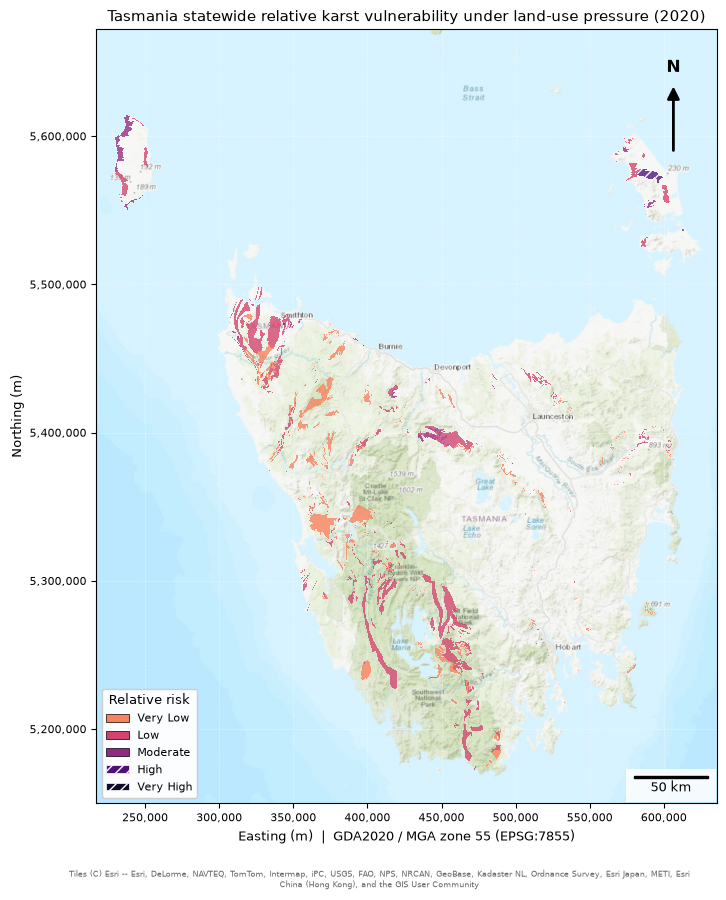

In [7]:
risk_class, edges, LABELS = classify_fixed(risk, risk_valid)

print("Class distribution (% of valid Tasmania land area):")
for i, label in enumerate(LABELS):
    n = (risk_class == i).sum()
    print(f"  {label}: {n} cells ({n/risk_valid.sum()*100:.2f}%)")

out_profile = template_profile.copy()
out_profile.update(dtype="uint8", nodata=255)
with rasterio.open(outpath / "risk_class_tas_2020_100m_EPSG7855.tif", "w", **out_profile) as dst:
    dst.write(risk_class, 1)

risk_profile = template_profile.copy()
risk_out = np.where(risk_valid, risk, template_profile["nodata"]).astype("float32")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif", "w", **risk_profile) as dst:
    dst.write(risk_out, 1)

left, right, bottom, top = raster_extent(template_profile["transform"], risk_class.shape)
fig, ax = plt.subplots(figsize=(8, 9))
add_basemap(ax, (left, bottom, right, top), margin=10000, zoom=8)
plot_risk(ax, risk_class, template_profile["transform"])
ax.set_title("Tasmania statewide relative karst vulnerability under land-use pressure (2020)", fontsize=11)
risk_legend(ax, LABELS, loc="lower left")
style_map_axes(ax)
add_scalebar(ax, 50000, "50 km")
add_north_arrow(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

### Continuous view

The same statewide risk on a continuous colour ramp, on the fixed 0-1 scale used for the classed map and for Mole Creek (Stage 6).


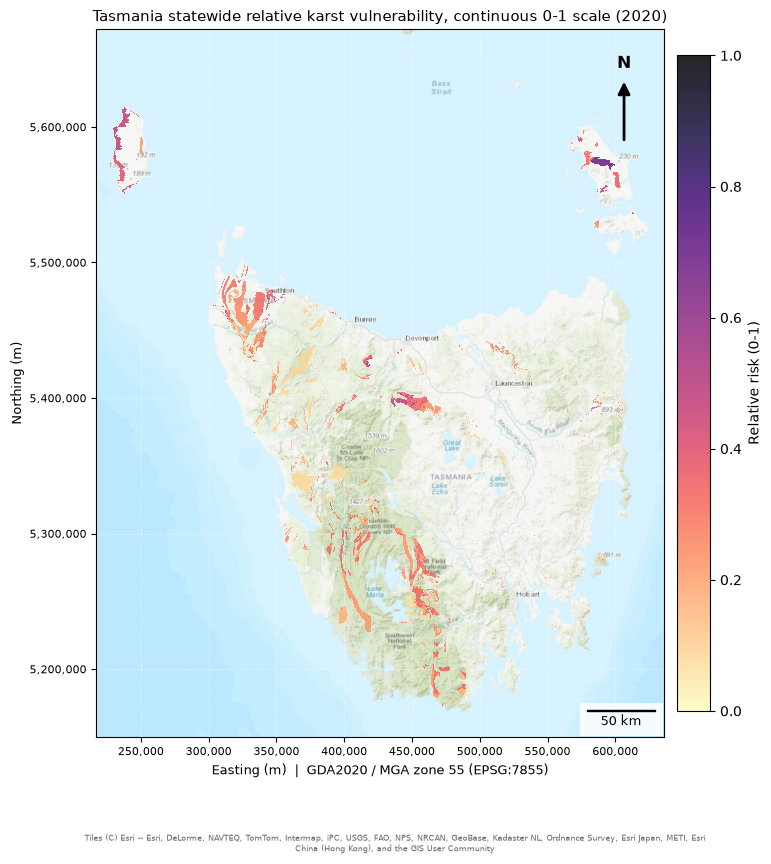

In [8]:
left, right, bottom, top = raster_extent(template_profile["transform"], risk.shape)
fig, ax = plt.subplots(figsize=(8, 9))
add_basemap(ax, (left, bottom, right, top), margin=10000, zoom=8)
image = plot_risk_continuous(ax, risk, template_profile["transform"])
add_risk_colourbar(ax, image)
ax.set_title("Tasmania statewide relative karst vulnerability, continuous 0-1 scale (2020)", fontsize=11)
style_map_axes(ax)
add_scalebar(ax, 50000, "50 km")
add_north_arrow(ax)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

## 7.7 Plausibility check: named karst areas, statewide

Same check as Stage 6, now over all statewide karst polygons. Aggregation is pooled: all polygons sharing a name are masked together in one operation, matching Stage 6.

In [9]:
karst_only = karst[karst["karst_intensity"] > 0].copy()

rows = []
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    for name, group in karst_only.groupby("KNAME"):
        out_image, _ = mask(src, list(group.geometry), crop=True, nodata=risk_profile["nodata"])
        vals_ = out_image[0]
        vals_ = vals_[vals_ != risk_profile["nodata"]]
        rows.append({"KNAME": name, "mean_risk": vals_.mean() if len(vals_) else np.nan, "n_pixels": len(vals_)})

named_risk = pd.DataFrame(rows).sort_values("mean_risk", ascending=False)
n_missing = named_risk["mean_risk"].isna().sum()
print(f"Named systems with zero valid pixels (too small for this raster's cell size, silently excluded from ranking): {n_missing}")
print("\nTop 15 statewide karst areas by mean risk:")
print(named_risk.head(15).to_string(index=False))

Named systems with zero valid pixels (too small for this raster's cell size, silently excluded from ranking): 8

Top 15 statewide karst areas by mean risk:
                         KNAME  mean_risk  n_pixels
Welcome River (1) / Port Hills   0.750000         2
                  Vinegar Hill   0.750000         9
            Emita - Memana (2)   0.694615      7502
                 Doctors Rocks   0.647665        71
   Irishtown - Sedgy Creek (2)   0.634849       106
                  Grim-Trefoil   0.625000        11
   Irishtown - Sedgy Creek (3)   0.613636        11
                 Flowery Gully   0.577099       120
                    Port Hills   0.571429        57
              Mt Stanley Creek   0.552826        14
  Mole Creek  (Chudleigh Hill)   0.529914        13
          Fairview (Redpa) (2)   0.524751       207
                  Geilston Bay   0.500000         2
      Fairview (Redpa) (1 & 2)   0.499095        94
                      Puncheon   0.481638       132


## What this statewide run can and can't say about Mole Creek

**Mole Creek (Chudleigh Hill)** and **Mole Creek** both rank near the top statewide. Mole Creek is a subset of this statewide computation, using the same data and the same frozen formula, so this shows the model is internally consistent, not that it replicates independently. An independent check would need a signal the model never saw (e.g. cave or doline density from the Karst Index Database, KID), which is out of scope here.

**Observation:** most of the other statewide top spots (Welcome River, Fairview/Redpa, Irishtown-Sedgy Creek, Sawards Creek, Brittons Swamp) sit in the **Smithton Basin / far northwest**, the same agricultural-karst region flagged in the earliest brainstorming for this project, before Mole Creek was chosen as the prototype.

## Stage 7 outputs

- `dem_tas_100m_EPSG7855.tif` — coarse statewide DEM template
- `risk_tas_2020_100m_EPSG7855.tif` — continuous statewide risk
- `risk_class_tas_2020_100m_EPSG7855.tif` — classified statewide risk

**Next (Stage 8):** compare this statewide-coarse output against the Mole-Creek-detailed result (Stage 6) for the Mole Creek area.